# Expert knowledge integration with Structure Estimation

Structure learning in causal inference seeks to uncover the causal relationships among variables. Though common methods like the PC algorithm and Hill-climb Search are useful, they often struggle due to limited data and increasing compute time as the models become more complex. Incorporating expert knowledg enhances the accuracy of the learned structure, and also speeds up the strucutre estimation process as we discard models that do not agree with our prior knowledge.

This tutorial walks through the process of accommodating expert knowledge with the structure estimation capabilities of pgmpy. Expert knowledge is most commonly used with the following algorithms:

- **PC**
- **Hill Climb Search**
- **GES**

The models used in this notebook are described in detail at [the bnlearn repository](https://www.bnlearn.com/bnrepository/).


### Expert knowledge with PC

In [25]:
from pgmpy.utils import get_example_model
from pgmpy.global_vars import logger
from networkx.drawing.nx_agraph import graphviz_layout
import logging
import matplotlib.pyplot as plt
import networkx as nx
import time


logger.setLevel(logging.ERROR)
nx_kwargs = {
    "with_labels": True,
    "node_size": 1500,
    "node_color": "white",
    "edgecolors": "black",
    "font_size": 10,
    "font_weight": "bold",
    "linewidths": 1,
    "connectionstyle": "arc3,rad=0.0",
}

  0%|          | 0/5 [00:00<?, ?it/s]

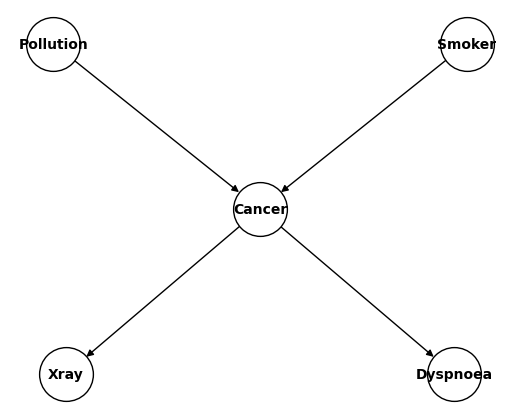

In [2]:
cancer = get_example_model("cancer")
cancer_samples = cancer.simulate(5000, seed=42)

pos = graphviz_layout(cancer, prog="dot")
plt.figure(figsize=(5, 4))
nx.draw(cancer, pos, **nx_kwargs)

Normal PC run

  0%|          | 0/5 [00:00<?, ?it/s]

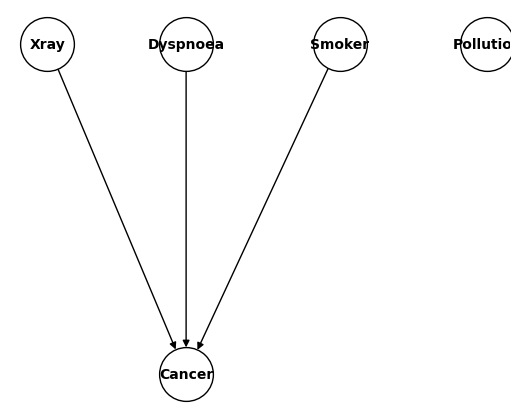

In [3]:
from pgmpy.estimators import PC, ExpertKnowledge

learned_model = PC(cancer_samples).estimate()

pos = graphviz_layout(learned_model, prog="dot")
plt.figure(figsize=(5, 4))
nx.draw(learned_model, pos, **nx_kwargs)

Using expert knowledge in the form of a temporal order 

  0%|          | 0/5 [00:00<?, ?it/s]

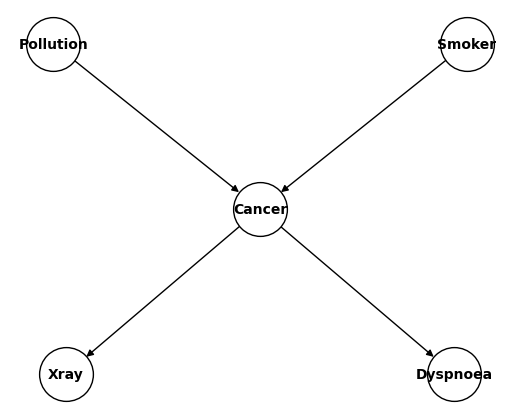

In [4]:
expert_knowledge = ExpertKnowledge(
    temporal_order=[["Pollution", "Smoker", "Cancer"], ["Dyspnoea", "Xray"]]
)
# e.g. we know only "Pollution", "Smoker", "Cancer" can be the causes of others

cancer_estimated = PC(cancer_samples).estimate(
    max_cond_vars=4, expert_knowledge=expert_knowledge
)

pos = graphviz_layout(cancer_estimated, prog="dot")
plt.figure(figsize=(5, 4))
nx.draw(cancer_estimated, pos, **nx_kwargs)

Note: Using any form of expert knowledge, especially with PC, is sensitive to the accuracy of the knowledge.

### Combined approach

  0%|          | 0/48 [00:00<?, ?it/s]

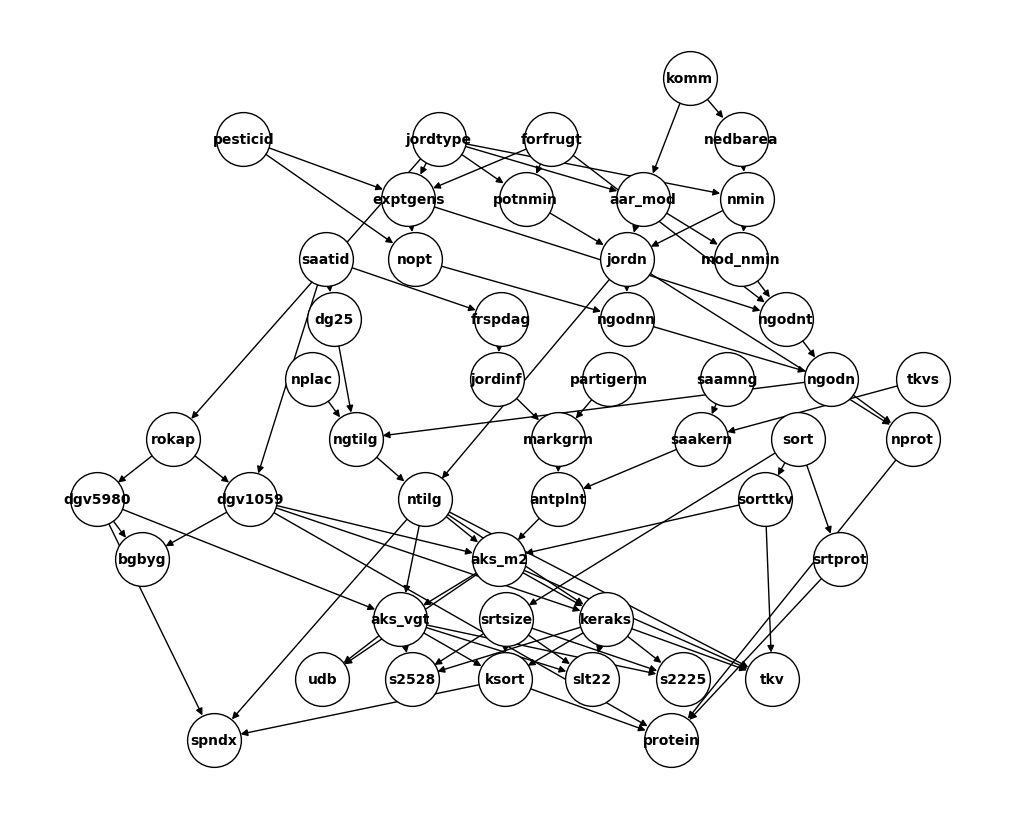

In [29]:
barley = get_example_model("barley")
barley_samples = barley.simulate(5000, seed=42)

pos = graphviz_layout(barley, prog="dot")
plt.figure(figsize=(10, 8))
nx.draw(barley, pos, **nx_kwargs)

In [33]:
from pgmpy.metrics import SHD

t1 = time.time()
est_model = PC(barley_samples).estimate()
t2 = time.time()
shd = SHD(barley, est_model)

print(f"Time elapsed: {t2-t1} seconds")
print(f"SHD: {shd}")

  0%|          | 0/5 [00:00<?, ?it/s]

Time elapsed: 90.89924001693726 seconds
SHD: 62


Combined approach

An alternative approach could be to first get a skeleton using the first phase of PC. The skeleton is simply the set of edges between nodes that are dependent(causal). This skeleton can be used as the search space for score-based methods like Hill Climb Search, thus reducing the workload in this phase (as we have already removed edges that are independent given some conditioning set). We get a reasonable result as compared to using only PC.

In [35]:
from pgmpy.estimators import HillClimbSearch

t1 = time.time()
skeleton, sep_sets = PC(barley_samples).estimate(return_type="skeleton")

expert_knowledge = ExpertKnowledge(search_space=skeleton.edges)
est_model = HillClimbSearch(barley_samples).estimate(expert_knowledge=expert_knowledge)
t2 = time.time()
shd = SHD(barley, est_model)

print(f"Time elapsed: {t2-t1} seconds")
print(f"SHD: {shd}")

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/1000000 [00:00<?, ?it/s]

Time elapsed: 90.74022889137268 seconds
SHD: 68


### Knowledge base of required and forbidden edges

  0%|          | 0/20 [00:00<?, ?it/s]

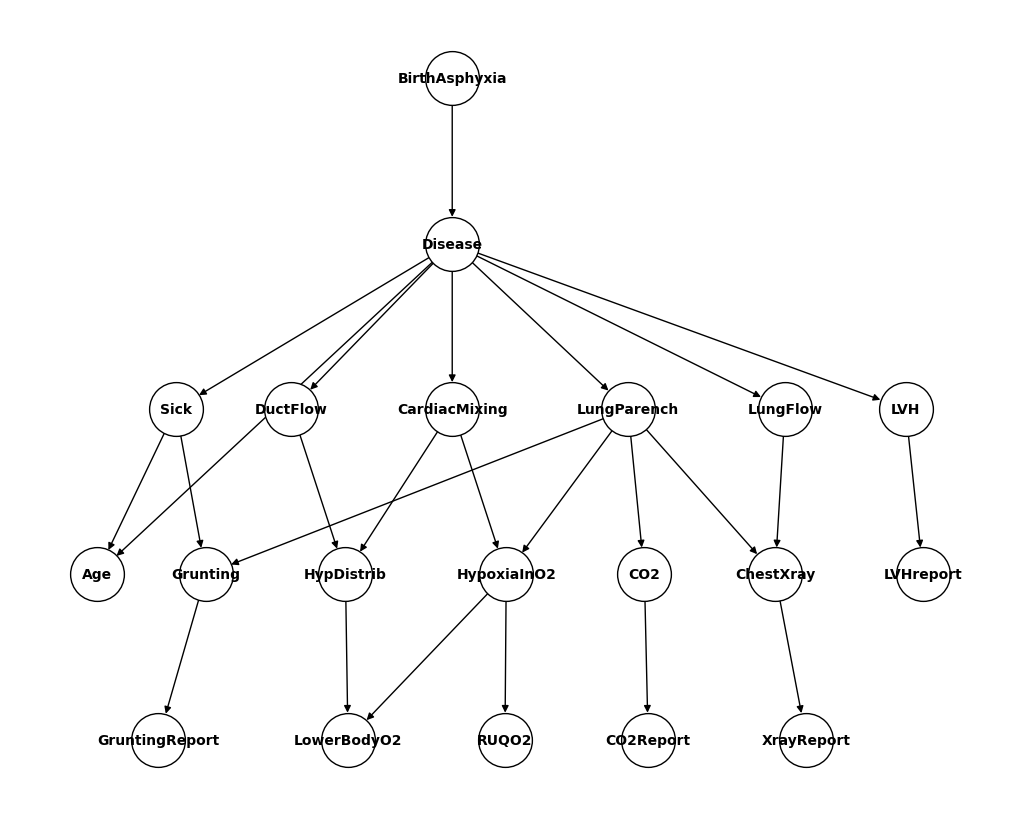

In [12]:
child = get_example_model("child")
child_samples = child.simulate(1000, seed=42)

pos = graphviz_layout(child, prog="dot")
plt.figure(figsize=(10, 8))
nx.draw(child, pos, **nx_kwargs)

In [ ]:
required_edges = [
    ("Disease", "Sick"),
    ("Disease", "DuctFlow"),
    ("Disease", "LungFlow"),
    ("Disease", "LungParench"),
    ("CO2", "CO2Report"),
]
forbidden_edges = [
    ("Disease", "BirthAsphyxia"),
    ("LVH", "Disease"),
]


expert_knowledge = ExpertKnowledge(
    required_edges=required_edges, forbidden_edges=forbidden_edges
)
est_model = HillClimbSearch(child_samples).estimate(expert_knowledge=expert_knowledge)
SHD(child, est_model)

  0%|          | 0/1000000 [00:00<?, ?it/s]

5

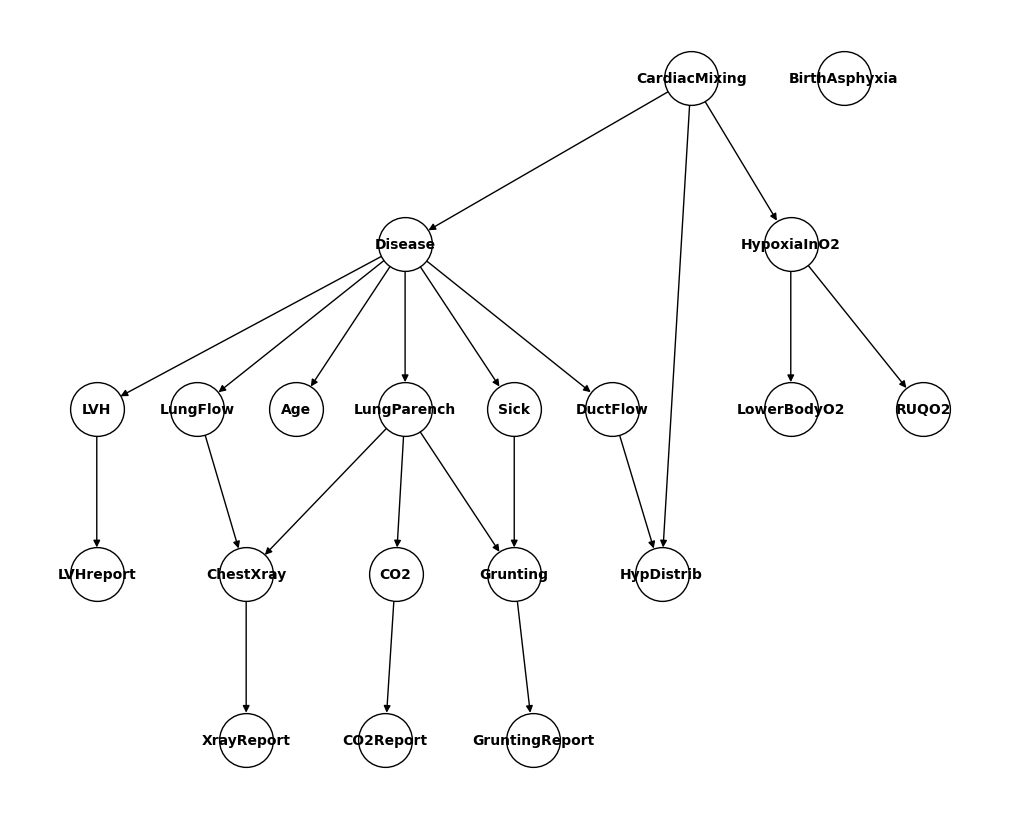

In [23]:
pos = graphviz_layout(est_model, prog="dot")
plt.figure(figsize=(10, 8))
nx.draw(est_model, pos, **nx_kwargs)